In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
from sklearn.metrics import precision_recall_curve


# Load dataset
df = pd.read_csv("GHW_HeartFailure_Readmission.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             1000 non-null   int64  
 1   Age                    1000 non-null   int64  
 2   Gender                 1000 non-null   object 
 3   Ethnicity              1000 non-null   object 
 4   Length_of_Stay         1000 non-null   int64  
 5   Previous_Admissions    1000 non-null   int64  
 6   Discharge_Disposition  1000 non-null   object 
 7   Pulse                  1000 non-null   int64  
 8   Temperature            1000 non-null   float64
 9   Heart_Rate             1000 non-null   int64  
 10  Systolic_BP            1000 non-null   int64  
 11  Diastolic_BP           1000 non-null   int64  
 12  Respiratory_Rate       1000 non-null   int64  
 13  BUN                    1000 non-null   int64  
 14  Creatinine             1000 non-null   float64
 15  Sodiu

In [2]:
# Preprocessing
df = df.dropna()
print(df['Readmission_30Days'].value_counts())

df = df.drop('Patient_ID', axis=1)

# Identify column types
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Calculate IQR for each numerical column and identify outliers
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter out rows with outliers for this column
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
df.head()

Readmission_30Days
0    713
1    287
Name: count, dtype: int64


,Age,Gender,Ethnicity,Length_of_Stay,Previous_Admissions,Discharge_Disposition,Pulse,Temperature,Heart_Rate,Systolic_BP,Diastolic_BP,Respiratory_Rate,BUN,Creatinine,Sodium,Hemoglobin,NT_proBNP,Ejection_Fraction,Readmission_30Days
0,83,1,3,7,4,3,119,37.1,147,160,99,27,11,0.61,127,13.1,2973,39,0
1,73,0,2,10,2,1,107,38.4,54,151,75,13,15,1.48,145,11.4,3220,56,0
2,59,0,4,5,1,0,63,39.0,118,112,57,21,26,1.54,147,10.9,1190,50,0
3,87,0,4,8,3,0,86,39.2,80,135,55,27,34,1.63,133,10.1,2934,29,1
4,52,0,0,1,1,1,117,38.5,94,145,79,16,32,2.57,146,12.8,4324,37,0


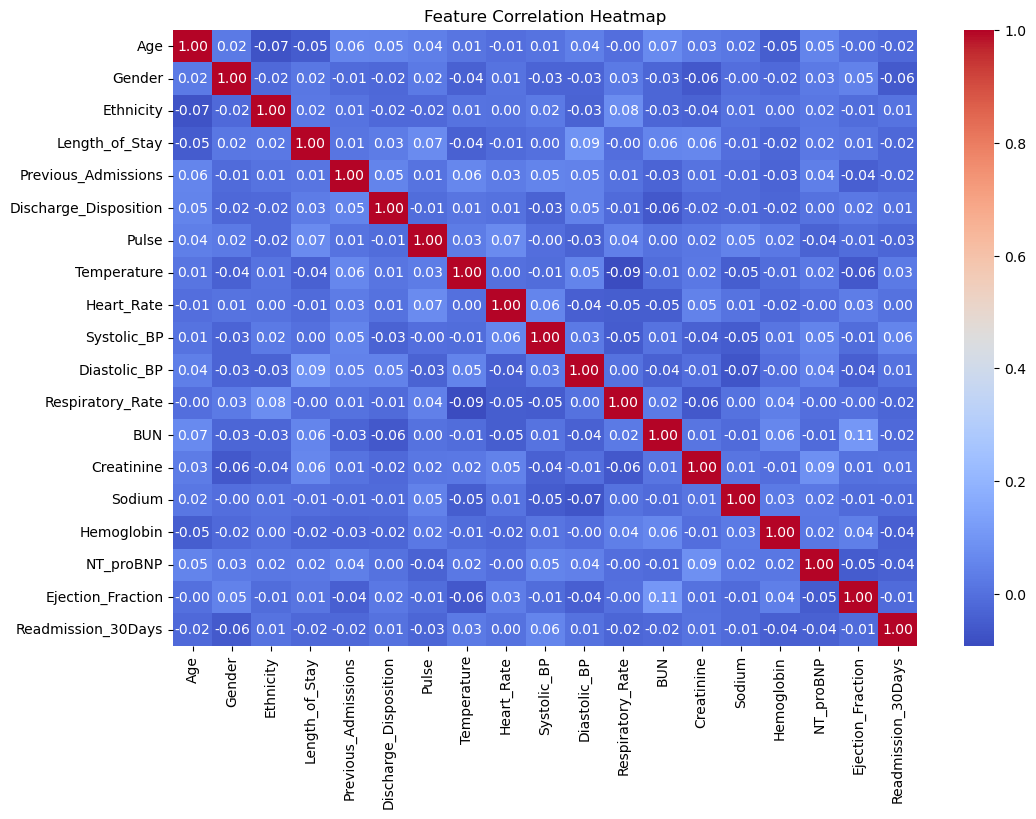

In [3]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [4]:
# Drop less important features
less_important = ['Discharge_Disposition', 'Ethnicity'] 
for col in less_important:
    df = df.drop(col, axis=1)  
df.head()

,Age,Gender,Length_of_Stay,Previous_Admissions,Pulse,Temperature,Heart_Rate,Systolic_BP,Diastolic_BP,Respiratory_Rate,BUN,Creatinine,Sodium,Hemoglobin,NT_proBNP,Ejection_Fraction,Readmission_30Days
0,83,1,7,4,119,37.1,147,160,99,27,11,0.61,127,13.1,2973,39,0
1,73,0,10,2,107,38.4,54,151,75,13,15,1.48,145,11.4,3220,56,0
2,59,0,5,1,63,39.0,118,112,57,21,26,1.54,147,10.9,1190,50,0
3,87,0,8,3,86,39.2,80,135,55,27,34,1.63,133,10.1,2934,29,1
4,52,0,1,1,117,38.5,94,145,79,16,32,2.57,146,12.8,4324,37,0


In [5]:
# Prepare features and target
X = df.drop('Readmission_30Days', axis=1)  
y = df['Readmission_30Days'] 

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest with Class Weights
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

# Hyperparameter Tuning using RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(rf, param_grid, n_iter=10, cv=3, random_state=42)
random_search.fit(X_train, y_train)

# Best Random Forest model
best_rf = random_search.best_estimator_

# Adjust Decision Threshold
y_pred_prob_rf = best_rf.predict_proba(X_test)[:, 1]  # Get predicted probabilities for class 1
y_pred_rf_adjusted = (y_pred_prob_rf > 0.3).astype(int)  # Adjust threshold to 0.3

# XGBoost Model
xgb_model = xgb.XGBClassifier(scale_pos_weight=10, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict using XGBoost
y_pred_xgb = xgb_model.predict(X_test)
y_pred_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]  # Get predicted probabilities for class 1
y_pred_xgb_adjusted = (y_pred_prob_xgb > 0.3).astype(int)  # Adjust threshold to 0.3

# Evaluate Random Forest
print("Random Forest - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_adjusted))
print("\nRandom Forest - Classification Report:")
print(classification_report(y_test, y_pred_rf_adjusted))

# Evaluate XGBoost
print("XGBoost - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_adjusted))
print("\nXGBoost - Classification Report:")
print(classification_report(y_test, y_pred_xgb_adjusted))

Random Forest - Confusion Matrix:
[[53 90]
 [22 35]]

Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.37      0.49       143
           1       0.28      0.61      0.38        57

    accuracy                           0.44       200
   macro avg       0.49      0.49      0.44       200
weighted avg       0.59      0.44      0.46       200

XGBoost - Confusion Matrix:
[[79 64]
 [34 23]]

XGBoost - Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.55      0.62       143
           1       0.26      0.40      0.32        57

    accuracy                           0.51       200
   macro avg       0.48      0.48      0.47       200
weighted avg       0.58      0.51      0.53       200



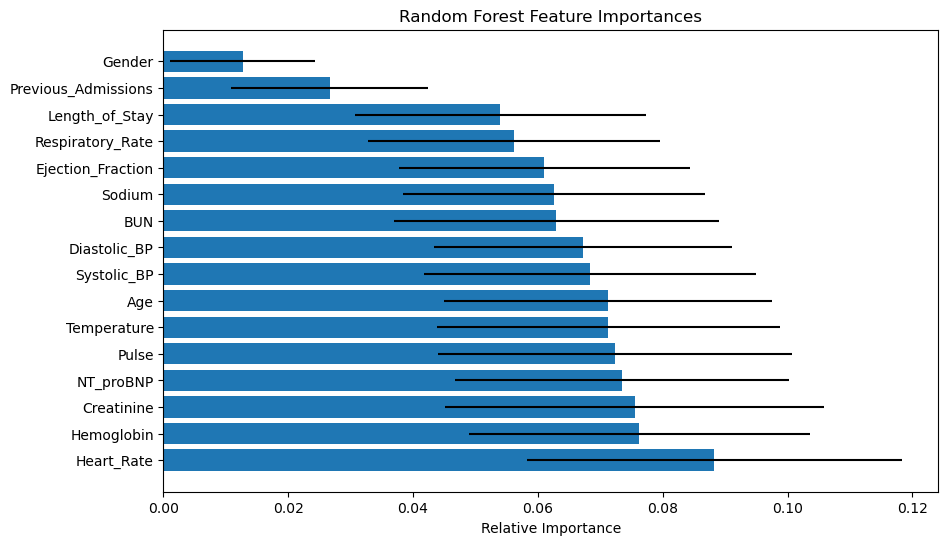

In [6]:
import matplotlib.pyplot as plt
import numpy as np

importances = best_rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in best_rf.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

# Plotting
plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importances")
plt.barh(range(X_train.shape[1]), importances[indices], xerr=std[indices], align="center")
plt.yticks(range(X_train.shape[1]), [X_train.columns[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

       Heart_Rate    NT_proBNP        Pulse   Creatinine          Age  \
count  1000.00000  1000.000000  1000.000000  1000.000000  1000.000000   
mean     98.77000  2552.547000    84.714000     1.772730    67.000000   
std      29.20853  1416.044376    20.022465     0.715125    12.945562   
min      50.00000   100.000000    50.000000     0.500000    45.000000   
25%      74.00000  1352.750000    67.000000     1.190000    56.000000   
50%      97.00000  2546.000000    85.000000     1.770000    68.000000   
75%     125.00000  3747.250000   102.000000     2.380000    78.000000   
max     149.00000  4997.000000   119.000000     3.000000    89.000000   

       Systolic_BP  Hemoglobin  
count  1000.000000  1000.00000  
mean    135.493000    12.53170  
std      25.956303     2.58824  
min      90.000000     8.00000  
25%     112.000000    10.40000  
50%     136.000000    12.60000  
75%     159.000000    14.80000  
max     179.000000    17.00000  


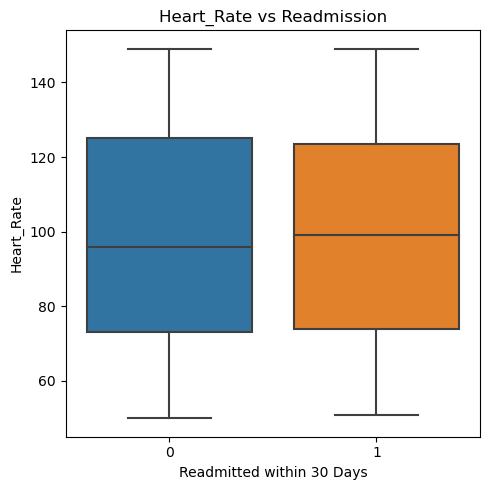

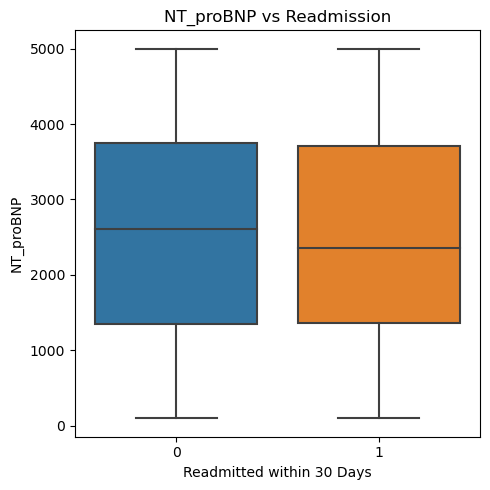

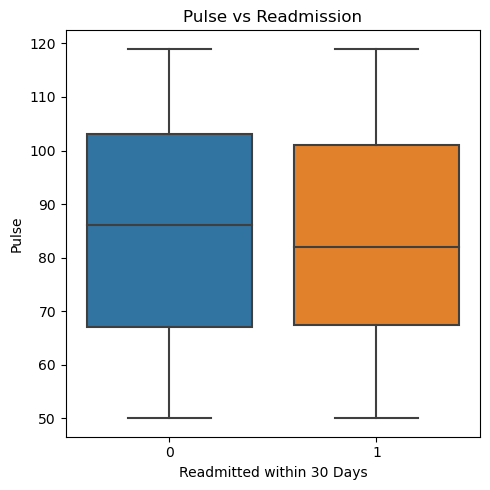

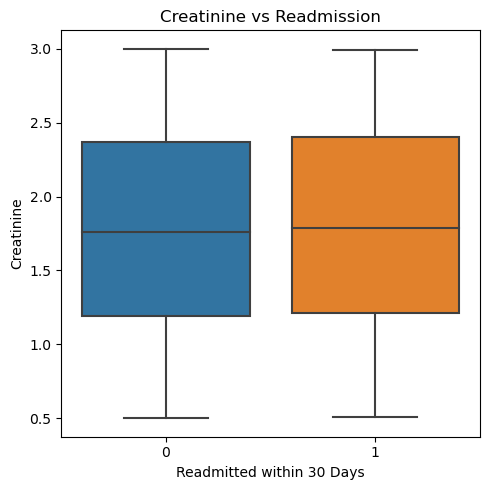

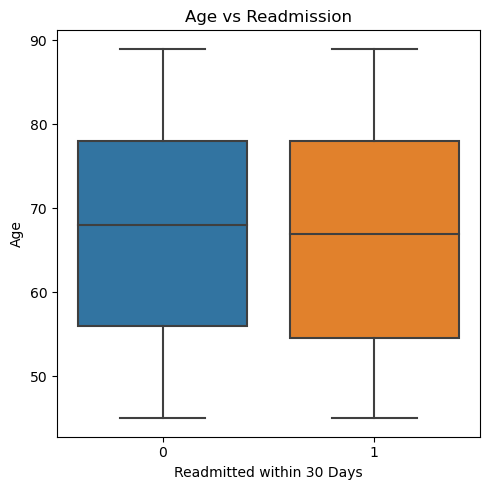

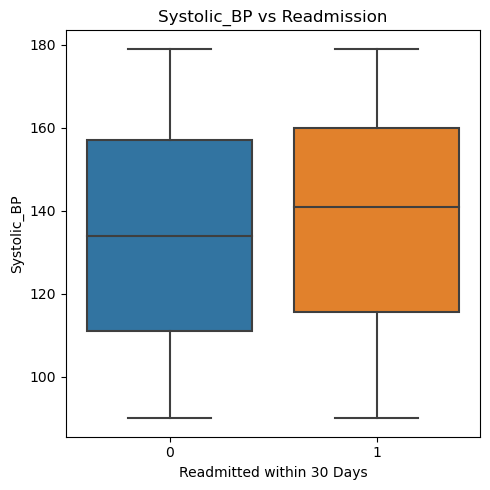

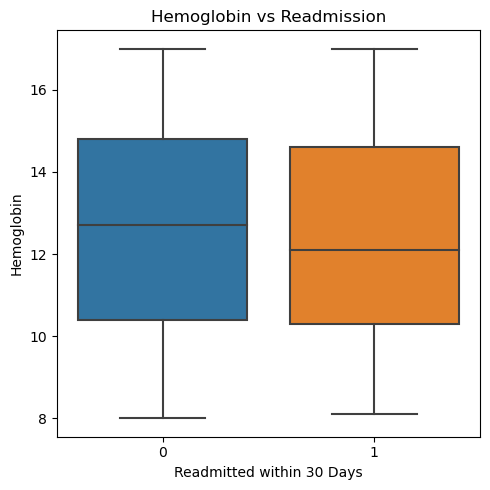

In [6]:
# List of important features
important_features = ['Heart_Rate', 'NT_proBNP', 'Pulse', 'Creatinine', 'Age', 'Systolic_BP', 'Hemoglobin']

# Descriptive statistics for important features in the DataFrame
print(df[important_features].describe())

# Boxplots for each feature vs. Readmission_30Days
for feature in important_features:
    plt.figure(figsize=(5, 5))
    sns.boxplot(x='Readmission_30Days', y=feature, data=df)
    plt.title(f'{feature} vs Readmission')
    plt.xlabel('Readmitted within 30 Days')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()


/Users/yo/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/Users/yo/anaconda3/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/Users/yo/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


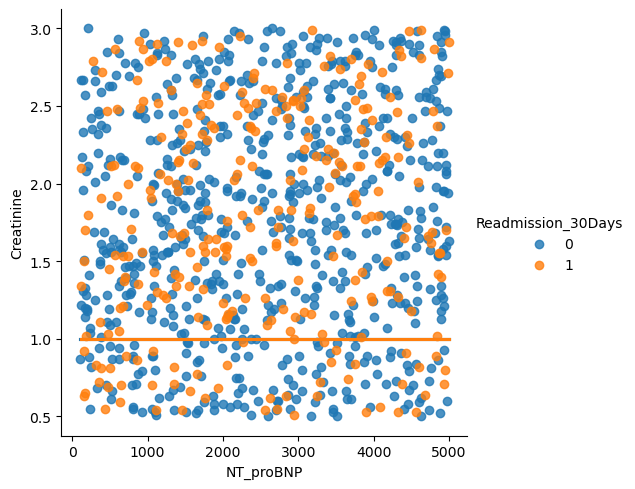

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(x='NT_proBNP', y='Creatinine', hue='Readmission_30Days', data=df, logistic=True)

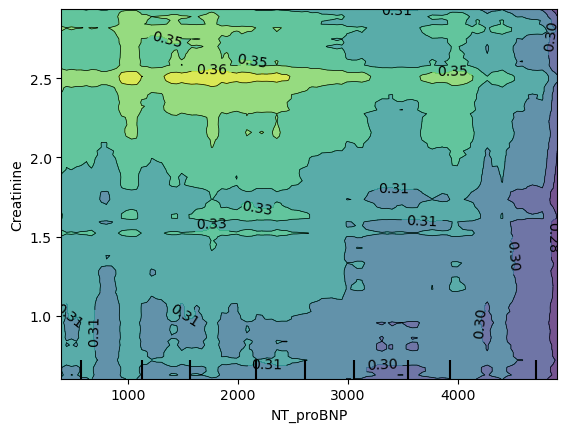

In [17]:
from sklearn.inspection import PartialDependenceDisplay

features = [('NT_proBNP', 'Creatinine')]  # interaction pair
PartialDependenceDisplay.from_estimator(best_rf, X_test, features)


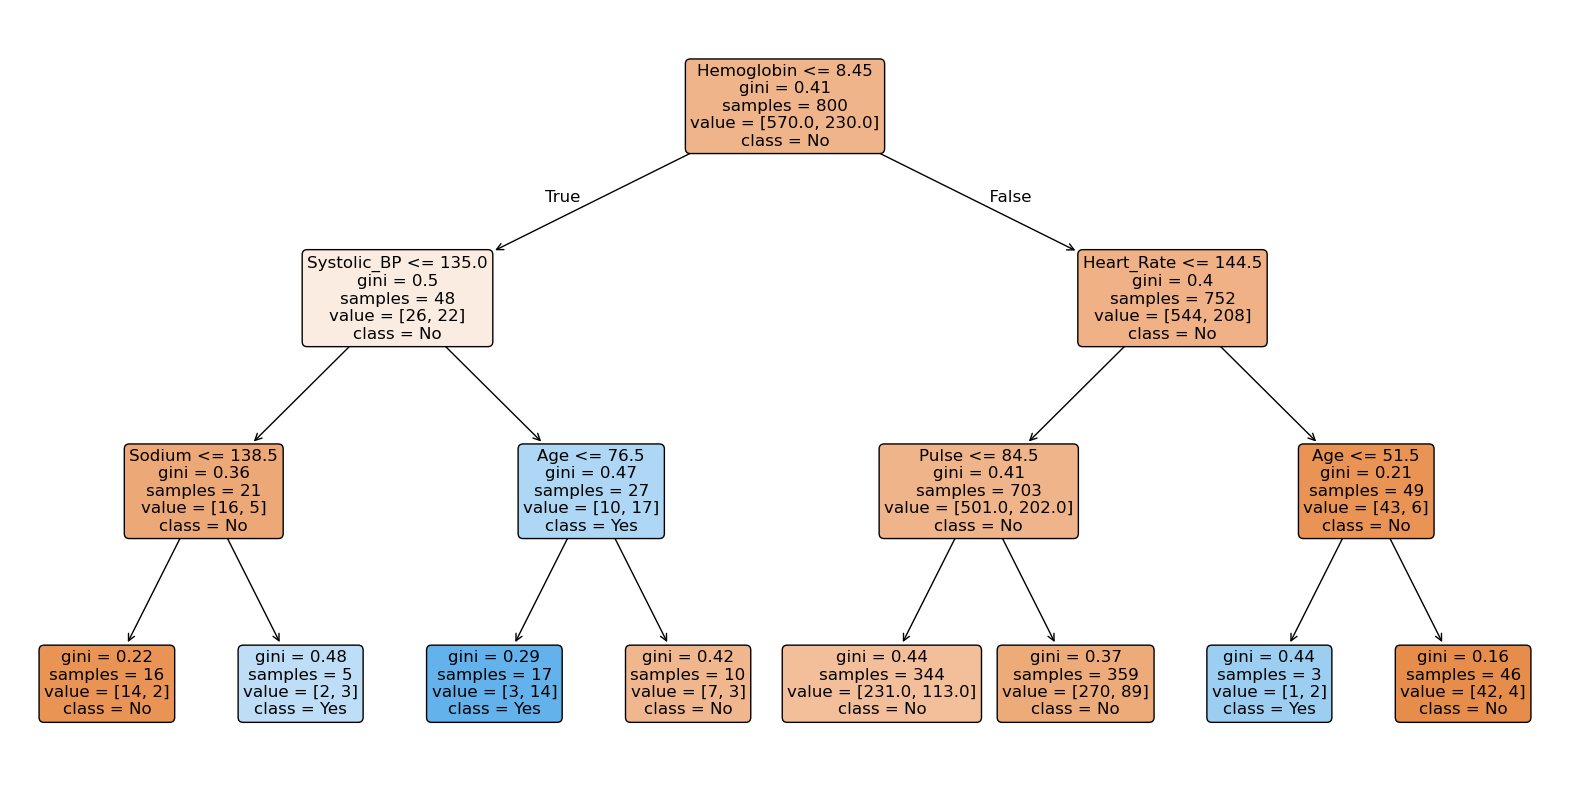

In [18]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))  # Increase size for clarity
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,            # Round box edges
    precision=2,             # Limit decimals in node info
    fontsize=12              # Increase font size
)
plt.show()


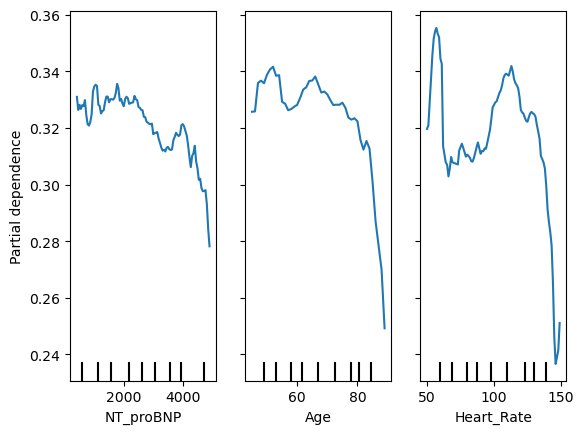

In [15]:
# Partial Dependence Plot to See Thresholds and Nonlinear Effects
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    best_rf, 
    X_test, 
    features=['NT_proBNP', 'Age', 'Heart_Rate'],
    kind='average'
)

In [16]:
import pandas as pd

X_test_copy = X_test.copy()
X_test_copy['NT_proBNP_bin'] = pd.qcut(X_test['NT_proBNP'], q=4)
X_test_copy['Readmission'] = y_test.values

# Readmission rate by bin
print(X_test_copy.groupby('NT_proBNP_bin')['Readmission'].mean())


NT_proBNP_bin
(146.999, 1397.25]    0.28
(1397.25, 2611.0]     0.30
(2611.0, 3704.0]      0.28
(3704.0, 4997.0]      0.28
Name: Readmission, dtype: float64
